In [1]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Results & Discussion (Summary)
</span></h3>

In [2]:
SAVE_DIR = "../../data/Georgios/pcy_recomender"

summary = pd.read_csv(os.path.join(SAVE_DIR, "eval_comparison_k5.csv"))
adaptive_p = pd.read_csv(os.path.join(SAVE_DIR, "adaptive_precision.csv"))
adaptive_f = pd.read_csv(os.path.join(SAVE_DIR, "adaptive_fbeta_b1.csv"))
seg_p = pd.read_csv(os.path.join(SAVE_DIR, "seg_alpha_precision.csv"))
seg_f = pd.read_csv(os.path.join(SAVE_DIR, "seg_alpha_fbeta_b1.csv"))

print("=== NOVEL/REPEAT/HYBRID @k=5 ===")
print(summary.to_string(index=False))

print("\n=== Segment α (precision vs Fβ) ===")
print("precision:", dict(zip(seg_p.segment, seg_p.alpha)))
print("Fβ:", dict(zip(seg_f.segment, seg_f.alpha)))

def _mean_safe(s): s=pd.Series(s).dropna(); return float(s.mean()) if not s.empty else float("nan")
print("\nMeans of per-user best metrics:")
print(pd.DataFrame([
    {"run":"precision",
     "mean_best_precision": _mean_safe(adaptive_p.best_precision),
     "mean_best_novelty":   _mean_safe(adaptive_p.best_novelty)},
    {"run":"fbeta(β=1.0)",
     "mean_best_precision": _mean_safe(adaptive_f.best_precision),
     "mean_best_novelty":   _mean_safe(adaptive_f.best_novelty)},
]).round(4).to_string(index=False))


=== NOVEL/REPEAT/HYBRID @k=5 ===
 alpha  Precision@5  Coverage@5  Novelty@5     F0.5
  0.00       0.3487         1.0     0.0513 0.161476
  0.05       0.3451         1.0     0.0645 0.184538
  0.10       0.3443         1.0     0.0721 0.196175
  0.15       0.3421         1.0     0.0848 0.212902
  0.20       0.3373         1.0     0.1052 0.234032
  0.25       0.3323         1.0     0.1361 0.257933
  0.30       0.3200         1.0     0.1828 0.278234
  0.35       0.3074         1.0     0.2280 0.287384
  0.40       0.2918         1.0     0.2788 0.289104
  0.45       0.2742         1.0     0.3252 0.283079
  0.50       0.2555         1.0     0.3707 0.272432
  0.55       0.2368         1.0     0.4190 0.259356
  0.60       0.2113         1.0     0.4777 0.237826
  0.65       0.1874         1.0     0.5318 0.215284
  0.70       0.1611         1.0     0.5874 0.188454
  0.75       0.1429         1.0     0.6242 0.168955
  0.80       0.1271         1.0     0.6587 0.151564
  0.85       0.1140         1.0

=== ANALYSIS REPORT ===
SAVE_DIR: ../../data/Georgios/pcy_recomender

--- NOVEL / REPEAT / HYBRID @k=5 ---
Strategy  alpha  Precision@5  Coverage@5  Novelty@5
       0   0.00       0.3487         1.0     0.0513
       1   0.05       0.3451         1.0     0.0645
       2   0.10       0.3443         1.0     0.0721
       3   0.15       0.3421         1.0     0.0848
       4   0.20       0.3373         1.0     0.1052
       5   0.25       0.3323         1.0     0.1361
       6   0.30       0.3200         1.0     0.1828
       7   0.35       0.3074         1.0     0.2280
       8   0.40       0.2918         1.0     0.2788
       9   0.45       0.2742         1.0     0.3252
      10   0.50       0.2555         1.0     0.3707
      11   0.55       0.2368         1.0     0.4190
      12   0.60       0.2113         1.0     0.4777
      13   0.65       0.1874         1.0     0.5318
      14   0.70       0.1611         1.0     0.5874
      15   0.75       0.1429         1.0     0.6242
      16 

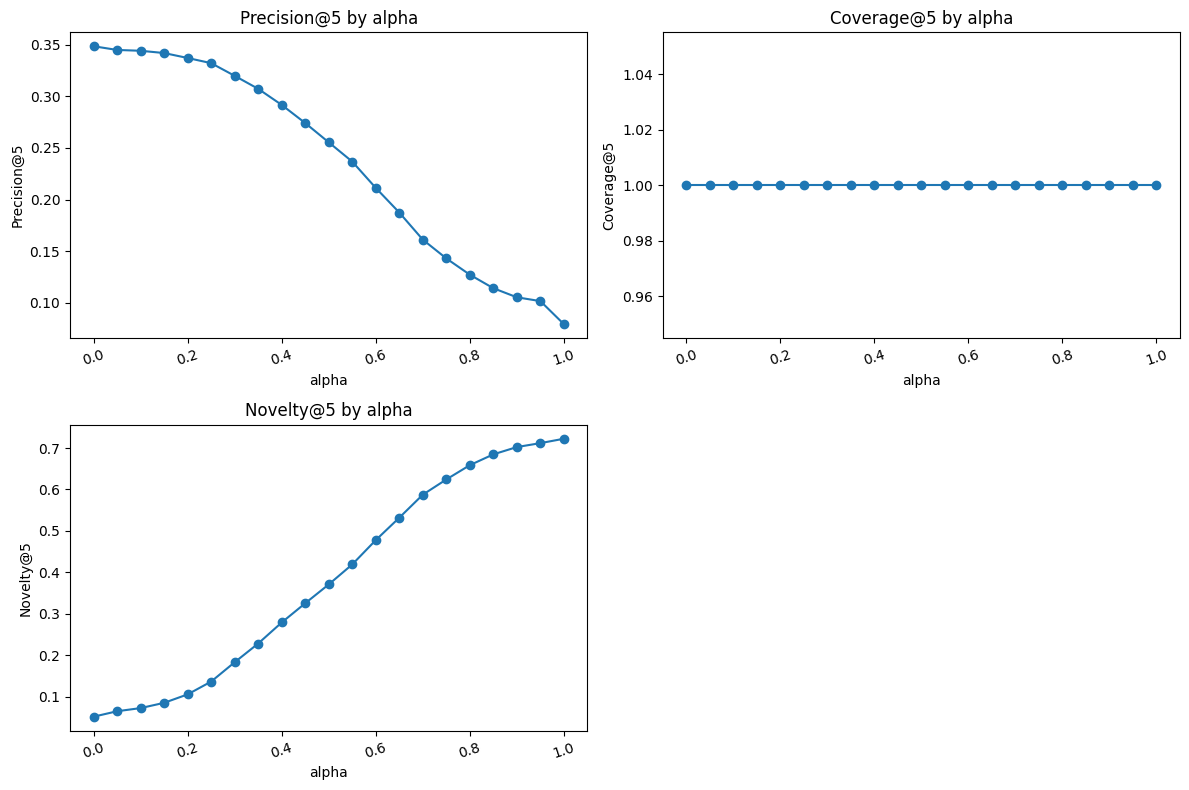


--- Segment α (precision vs Fβ=1.0) ---
    segment  alpha_precision  alpha_fbeta  delta
   explorer              0.0         0.00   0.00
heavy-mixed              0.0         0.40   0.40
light-mixed              0.0         0.35   0.35
   repeater              0.0         0.35   0.35

[NOTE] Segment alpha (precision) bars are all 0.0 — optimizing pure precision picked α=0 across segments, so the plot appears empty (zero-height bars).

--- Means of per-user best metrics ---
         run  mean_best_precision  mean_best_novelty
   precision               0.3528             0.0628
fbeta(β=1.0)               0.2753             0.3391


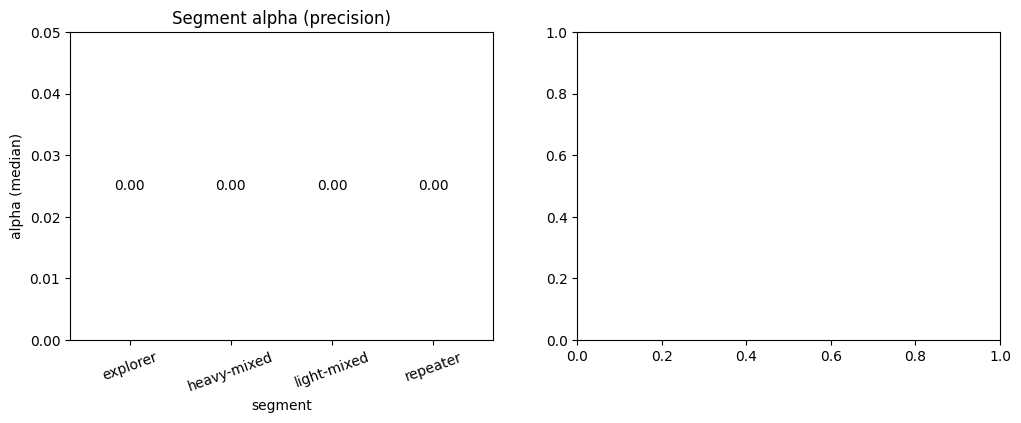

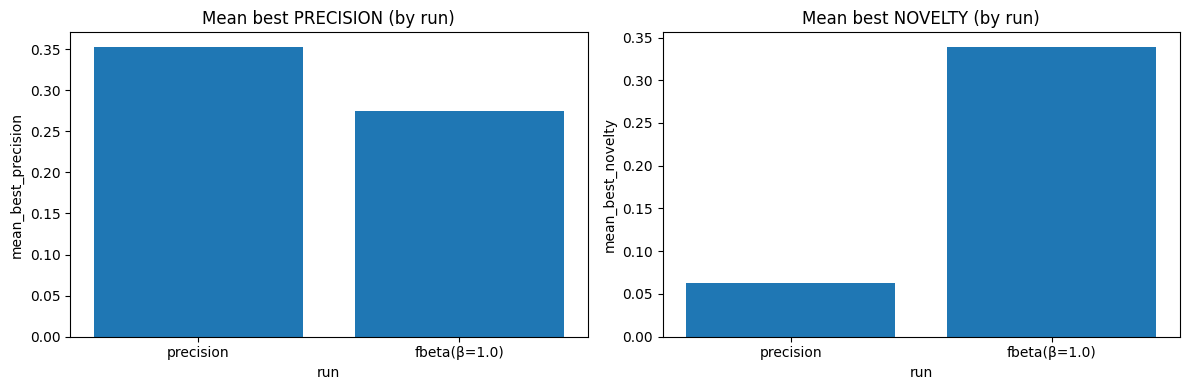


=== End of analysis ===


In [ ]:
# ---------- Helpers ----------
def _mean_safe(s):
    s = pd.Series(s).dropna()
    return float(s.mean()) if not s.empty else float("nan")

def _load_csv(name):
    path = os.path.join(SAVE_DIR, name)
    if not os.path.exists(path):
        print(f"[WARN] Missing file: {path}")
        return None
    try:
        df = pd.read_csv(path)
        df.columns = [str(c).strip() for c in df.columns]
        return df
    except Exception as e:
        print(f"[ERROR] Failed to read {path}: {e}")
        return None

def _ensure_strategy_col(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    out = df.copy()
    if "Strategy" in out.columns:
        return out
    if out.index.name and out.index.name.strip().lower() == "strategy":
        out = out.reset_index()
        out.rename(columns={out.columns[0]: "Strategy"}, inplace=True)
        return out
    like = [c for c in out.columns if str(c).strip().lower().startswith("strategy")]
    if like:
        out = out.rename(columns={like[0]: "Strategy"})
        return out
    out.insert(0, "Strategy", out.index.astype(str))
    return out.reset_index(drop=True)

def _grid(n, cols=2):
    rows = (n + cols - 1) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axs = np.atleast_1d(axs).ravel()
    return fig, axs, rows, cols

# Load data 
summary    = _load_csv("eval_comparison_k5.csv")
adaptive_p = _load_csv("adaptive_precision.csv")
adaptive_f = _load_csv("adaptive_fbeta_b1.csv")
seg_p      = _load_csv("seg_alpha_precision.csv")
seg_f      = _load_csv("seg_alpha_fbeta_b1.csv")

print("=== ANALYSIS REPORT ===")
print(f"SAVE_DIR: {SAVE_DIR}")

#  1) NOVEL vs REPEAT vs HYBRID summary 
if summary is None or summary.empty:
    print("\n[INFO] No evaluation summary found.")
else:
    summary = _ensure_strategy_col(summary)

    # Build the list of columns that actually exist in the CSV
    wanted = ["Strategy", "alpha", "Precision@5", "Coverage@5", "Novelty@5", "Diversity@5"]
    cols   = [c for c in wanted if c in summary.columns]

    # convert to numeric metrics (whatever is not Strategy/alpha)
    num_cols = [c for c in cols if c not in ("Strategy", "alpha")]
    for c in num_cols:
        summary[c] = pd.to_numeric(summary[c], errors="coerce")

    print("\n--- NOVEL / REPEAT / HYBRID @k=5 ---")
    # print only existing columns, rounded to 4 decimals, strategy/alpha first afterwards metrics
    lead = [c for c in ["Strategy", "alpha"] if c in cols]
    print(summary[lead + num_cols].round(4).to_string(index=False))

    # x axis dynamically: curve vs alpha or 3 bars per Strategy
    is_alpha_table = ("alpha" in summary.columns)
    metrics = num_cols

    fig, axs, _, _ = _grid(len(metrics), cols=2)
    for i, metric in enumerate(metrics):
        ax = axs[i]
        if is_alpha_table:
            x = pd.to_numeric(summary["alpha"], errors="coerce")
            y = pd.to_numeric(summary[metric], errors="coerce").fillna(0)
            ax.plot(x, y, marker="o")
            ax.set_xlabel("alpha")
        else:
            ax.bar(summary["Strategy"], summary[metric].fillna(0))
            ax.set_xlabel("Strategy")
        ax.set_title(f"{metric} by {'alpha' if is_alpha_table else 'Strategy'}")
        ax.set_ylabel(metric)
        for t in ax.get_xticklabels(): t.set_rotation(18)

    for j in range(len(metrics), len(axs)):
        axs[j].axis("off")
    plt.tight_layout(); plt.show()

#  2) Segment α comparison 
have_seg = (
    seg_p is not None and seg_f is not None and
    not seg_p.empty and not seg_f.empty and
    {"segment","alpha"}.issubset(seg_p.columns) and
    {"segment","alpha"}.issubset(seg_f.columns)
)

if have_seg:
    print("\n--- Segment α (precision vs Fβ=1.0) ---")
    segs = sorted(set(seg_p["segment"]).union(set(seg_f["segment"])))
    left  = {r["segment"]: r["alpha"] for _, r in seg_p.iterrows()}
    right = {r["segment"]: r["alpha"] for _, r in seg_f.iterrows()}
    cmp = pd.DataFrame({
        "segment": segs,
        "alpha_precision": [left.get(s, np.nan) for s in segs],
        "alpha_fbeta":     [right.get(s, np.nan) for s in segs],
    })
    cmp["delta"] = (cmp["alpha_fbeta"] - cmp["alpha_precision"]).round(3)
    print(cmp.to_string(index=False))

    fig, axs, _, _ = _grid(2, cols=2)

    #  precision chart with zero-baseline & labels when all zeros 
    ap = pd.to_numeric(cmp["alpha_precision"], errors="coerce")
    axs[0].bar(cmp["segment"], ap.fillna(0))
    axs[0].set_title("Segment alpha (precision)")
    axs[0].set_xlabel("segment"); axs[0].set_ylabel("alpha (median)")
    axs[0].tick_params(axis='x', rotation=20)

    max_ap = np.nanmax(ap.values) if len(ap) else 0.0
    if not np.isfinite(max_ap) or max_ap == 0.0:
        # All zero bars: set a thin visible baseline and write values on top
        axs[0].set_ylim(0, 0.05)
        for i, seg in enumerate(cmp["segment"]):
            axs[0].text(i, 0.025, "0.00", ha="center", va="center")


    #  Why the first chart may look empty? 
    if np.nanmax(cmp["alpha_precision"].values) == 0.0:
        print("\n[NOTE] Segment alpha (precision) bars are all 0.0 — "
              "optimizing pure precision picked α=0 across segments, "
              "so the plot appears empty (zero-height bars).")
else:
    print("\n[INFO] Segment-alpha CSVs not found or missing columns; skipping segment comparison.")

#  3) Means of per-user “best” metrics (precision vs Fβ) 
ok_p = adaptive_p is not None and not adaptive_p.empty
ok_f = adaptive_f is not None and not adaptive_f.empty

if ok_p and ok_f:
    mp = round(_mean_safe(adaptive_p.get("best_precision")), 4)
    npv = round(_mean_safe(adaptive_p.get("best_novelty")), 4)
    mf = round(_mean_safe(adaptive_f.get("best_precision")), 4)
    nf = round(_mean_safe(adaptive_f.get("best_novelty")), 4)
    means_df = pd.DataFrame([
        {"run": "precision",    "mean_best_precision": mp, "mean_best_novelty": npv},
        {"run": "fbeta(β=1.0)", "mean_best_precision": mf, "mean_best_novelty": nf},
    ])
    print("\n--- Means of per-user best metrics ---")
    print(means_df.to_string(index=False))

    fig, axs, _, _ = _grid(2, cols=2)
    axs[0].bar(means_df["run"], means_df["mean_best_precision"])
    axs[0].set_title("Mean best PRECISION (by run)")
    axs[0].set_xlabel("run"); axs[0].set_ylabel("mean_best_precision")

    axs[1].bar(means_df["run"], means_df["mean_best_novelty"])
    axs[1].set_title("Mean best NOVELTY (by run)")
    axs[1].set_xlabel("run"); axs[1].set_ylabel("mean_best_novelty")

    plt.tight_layout(); plt.show()
else:
    print("\n[INFO] Adaptive-run CSVs not found; skipping means section.")

print("\n=== End of analysis ===")


<h3> <span style="color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Alpha Sweep & Segmented α — What the Results Mean
</span></h3>

**Alpha sweep (global):** Precision@5 declines steadily as α increases from 0→1 (≈0.35→0.08), while Coverage@5 remains flat at 1.00 and Novelty@5 rises from ≈0.05→≈0.72. </br>
Interpretation: low α prioritizes **REPEAT** signals (high precision, low discovery), high α prioritizes **NOVEL** rules (high discovery, lower precision). </br>
Practical target: for F<sub>0.5</sub> (more weight on precision), the curve suggests a sweet spot around **α≈0.35–0.40** that preserves a good chunk of precision while unlocking mid-level novelty. </br>

**Segmented α (median by user segment):** With **precision-only** optimization, the median best α per segment is **0.00** across the board → i.e., </br>when judged purely on hit-rate, the model chooses to recommend repeats. That is expected on grocery data dominated by reorders. </br>
With **F<sub>1.0</sub> (precision≈novelty)**, segments shift to **heavy-mixed=0.40**, **light-mixed=0.35**, **repeater=0.35**, **explorer=0.00**. </br>
Implication: mixed/repeater users benefit from some novelty in the blend; explorers still appear volatile—consider enforcing an **α<sub>min</sub>≈0.20** to guarantee discovery exposure even if the median lands at 0.00. </br>

**Per-user “best” means (sanity check):** Optimizing precision yields **P=0.3528, N=0.0628** (high accuracy, little discovery). Optimizing F<sub>1.0</sub> yields **P=0.2753, N=0.3391** (balanced, significantly more discovery). </br>
Takeaway: the adaptive run trades ~0.08 absolute precision for ~0.28 absolute novelty—often a worthwhile swap when aiming for growth or cross-sell. </br>

**Recommended settings:** </br>
• Single default: **α≈0.35–0.40** when the KPI prefers accuracy with some exploration (F<sub>0.5</sub>-like). </br>
• Adaptive: use the **segment medians** above; optionally clip with **α∈[0.20, 0.80]** to avoid extreme modes (pure repeat or pure novel) in production. </br>

**Notes / next steps:** </br>
• The printed table is an **alpha sweep**; to also include the classic **3-row NOVEL/REPEAT/HYBRID** bars, export `eval_strategy_summary.csv` and re-run the analysis cell. </br>
• If novelty is still too low for explorers, raise their floor (e.g., α<sub>min</sub>=0.30) or add popularity caps/penalties to dampen overly common items. </br>
• Monitor weekly: precision drift and item diversity often change as new orders arrive; re-estimating segment α medians keeps the blend calibrated.